# 09 — CORAL Domain Adaptation (80/20 Design)

**CORAL (Correlation Alignment)** aligns the covariance structure of source (eICU) continuous features to match the target (MIMIC) distribution. Unlike Importance Weighting — which failed here because the domain classifier AUC = 1.000 makes weights collapse to near-uniform — CORAL does not require distributional overlap. It operates on second-order statistics (covariance matrices), not sample-level density ratios.

Extensions tested:
- **CORAL + LS** — CORAL alignment then label shift correction
- **CORAL + IW + LS** — add importance weights on top of CORAL-aligned data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q xgboost scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, os, pickle, json
warnings.filterwarnings('ignore')

from scipy.linalg            import sqrtm
from sklearn.ensemble        import RandomForestClassifier
from sklearn.calibration     import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics         import (roc_auc_score, average_precision_score,
                                     roc_curve, precision_recall_curve)

SEED = 42
np.random.seed(SEED)

BASE      = '/content/drive/MyDrive/AI in Medicine/data/output_data/preprocessed'
MODEL_DIR = '/content/drive/MyDrive/AI in Medicine/models'
CORAL_DIR = f'{MODEL_DIR}/coral_80'
os.makedirs(CORAL_DIR, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data and Preprocessing Objects

In [ ]:
X_train = pd.read_csv(f'{BASE}/X_train_80.csv')
y_train = pd.read_csv(f'{BASE}/y_train_80.csv').squeeze()
X_val   = pd.read_csv(f'{BASE}/X_val_80.csv')
y_val   = pd.read_csv(f'{BASE}/y_val_80.csv').squeeze()
X_mimic = pd.read_csv(f'{BASE}/X_mimic_80.csv')
y_mimic = pd.read_csv(f'{BASE}/y_mimic_80.csv').squeeze()

with open(f'{BASE}/preprocessing_objects_80.pkl', 'rb') as f:
    prep = pickle.load(f)

with open(f'{MODEL_DIR}/model_params_80.json') as f:
    params = json.load(f)

log_odds_shift = params['log_odds_shift']
MIMIC_THR      = params['mimic_threshold']
RF_CAL_THR     = params['rf_cal_threshold']
best_rf_params = params['rf_best_params']

with open(f'{MODEL_DIR}/rf_calibrated_80.pkl', 'rb') as f:
    rf_cal = pickle.load(f)

with open(f'{MODEL_DIR}/extensions_80/extension_models_80.pkl', 'rb') as f:
    ext = pickle.load(f)
iw_weights = ext['iw_weights'].astype(np.float64)

# continuous columns = those that were scaled (not binary flags / OHE dummies)
cont_cols = [c for c in prep.get('continuous_cols', []) if c in X_train.columns]
print(f'Continuous features for CORAL: {len(cont_cols)}')
print(f'IW weights: min={iw_weights.min():.3f}  max={iw_weights.max():.3f}  mean={iw_weights.mean():.3f}')

# helpers
def apply_ls(probs, shift=log_odds_shift):
    lo = np.log(np.clip(probs, 1e-9, 1-1e-9) / (1 - np.clip(probs, 1e-9, 1-1e-9)))
    return 1 / (1 + np.exp(-(lo + shift)))

def youden_thr(y, probs):
    fpr, tpr, thrs = roc_curve(y, probs)
    return float(thrs[np.argmax(tpr - fpr)])

def evaluate(y_true, probs, thr, label=''):
    auc  = roc_auc_score(y_true, probs)
    pr   = average_precision_score(y_true, probs)
    pred = (probs >= thr).astype(int)
    sens = float((pred[y_true==1] == 1).mean())
    spec = float((pred[y_true==0] == 0).mean())
    print(f'{label:<45}  AUC={auc:.3f}  PR={pr:.3f}  Sens={sens:.3f}  Spec={spec:.3f}')
    return {'auc': auc, 'pr': pr, 'sens': sens, 'spec': spec}

Continuous features for CORAL: 46
IW weights: min=0.997  max=2.587  mean=1.000


## 2. CORAL Implementation

CORAL aligns source covariance to target covariance via the transform:

$$X_s^{\text{aligned}} = X_s \cdot C_s^{-1/2} \cdot C_t^{1/2}$$

where $C_s$ = source covariance, $C_t$ = target covariance. Applied **only to continuous features** — binary flags and OHE dummies are left unchanged.

In [ ]:
def coral_align(X_src, X_tgt, cont_cols, reg=1e-4):
    """
    Align X_src continuous features to match X_tgt covariance structure.
    Returns aligned copy of X_src and the transform matrix W.
    """
    cols = [c for c in cont_cols if c in X_src.columns and c in X_tgt.columns]
    Xs = X_src[cols].values.astype(float)
    Xt = X_tgt[cols].values.astype(float)

    Cs = np.cov(Xs.T) + reg * np.eye(len(cols))
    Ct = np.cov(Xt.T) + reg * np.eye(len(cols))

    # W = Cs^(-1/2) @ Ct^(1/2)
    Cs_inv_sqrt = np.real(np.linalg.inv(sqrtm(Cs)))
    Ct_sqrt     = np.real(sqrtm(Ct))
    W = Cs_inv_sqrt @ Ct_sqrt

    X_aligned = X_src.copy()
    X_aligned[cols] = Xs @ W
    return X_aligned, W, cols

# align eICU train and val to MIMIC distribution
X_train_c, W, coral_cols = coral_align(X_train, X_mimic, cont_cols)
X_val_c,   _, _          = coral_align(X_val,   X_mimic, cont_cols)
# MIMIC is the target — no alignment needed

# measure covariance distance before vs after
Cs_before = np.cov(X_train[coral_cols].values.T)
Cs_after  = np.cov(X_train_c[coral_cols].values.T)
Ct        = np.cov(X_mimic[coral_cols].values.T)
frob_before = float(np.linalg.norm(Cs_before - Ct, 'fro'))
frob_after  = float(np.linalg.norm(Cs_after  - Ct, 'fro'))
reduction   = (frob_before - frob_after) / frob_before * 100

print(f'Aligned {len(coral_cols)} continuous features')
print(f'Frobenius ||Cs - Ct|| before CORAL : {frob_before:.2f}')
print(f'Frobenius ||Cs - Ct|| after  CORAL : {frob_after:.2f}')
print(f'Covariance distance reduction      : {reduction:.1f}%')

Aligned 46 continuous features
Frobenius ||Cs - Ct|| before CORAL : 18.91
Frobenius ||Cs - Ct|| after  CORAL : 0.00
Covariance distance reduction      : 100.0%


## 3. Train RF on CORAL-Aligned eICU

In [ ]:
rf_coral     = RandomForestClassifier(**best_rf_params, class_weight='balanced',
                                       random_state=SEED, n_jobs=-1)
rf_coral_cal = CalibratedClassifierCV(rf_coral, method='sigmoid', cv=5)
rf_coral_cal.fit(X_train_c, y_train)
print('RF trained on CORAL-aligned eICU.')

p_coral_val      = rf_coral_cal.predict_proba(X_val_c)[:, 1]
p_coral_mimic_ls = apply_ls(rf_coral_cal.predict_proba(X_mimic)[:, 1])
coral_val_thr    = youden_thr(y_val, p_coral_val)

# reference
p_ref_val      = rf_cal.predict_proba(X_val)[:, 1]
p_ref_mimic_ls = apply_ls(rf_cal.predict_proba(X_mimic)[:, 1])

print('\nResults:')
ref_val_res    = evaluate(y_val,   p_ref_val,       RF_CAL_THR,   'Baseline RF — Val')
ref_mimic_res  = evaluate(y_mimic, p_ref_mimic_ls,  MIMIC_THR,    'Baseline RF — MIMIC (LS)')
print()
coral_val_res  = evaluate(y_val,   p_coral_val,     coral_val_thr,'CORAL RF — Val')
coral_mimic_res= evaluate(y_mimic, p_coral_mimic_ls,MIMIC_THR,    'CORAL RF — MIMIC (LS)')

RF trained on CORAL-aligned eICU.

Results:
Baseline RF — Val                              AUC=0.826  PR=0.432  Sens=0.640  Spec=0.904
Baseline RF — MIMIC (LS)                       AUC=0.734  PR=0.642  Sens=0.674  Spec=0.678

CORAL RF — Val                                 AUC=0.814  PR=0.359  Sens=0.680  Spec=0.894
CORAL RF — MIMIC (LS)                          AUC=0.733  PR=0.629  Sens=0.630  Spec=0.733


## 4. CORAL + IW + LS

Combine CORAL alignment with importance weighting. The IW weights from notebook 04b were computed on the original (unaligned) feature space. We reuse them here as sample weights — they still encode which training samples are more representative of MIMIC patients.

In [ ]:
print(f'IW weight range: min={iw_weights.min():.4f}  max={iw_weights.max():.4f}  std={iw_weights.std():.4f}')
print('Note: narrow weight range (std~0.06) confirms IW near-uniform — extreme separability limits its effect.')

rf_ciw     = RandomForestClassifier(**best_rf_params, class_weight=None,
                                    random_state=SEED, n_jobs=-1)
rf_ciw_cal = CalibratedClassifierCV(rf_ciw, method='sigmoid', cv=5)
rf_ciw_cal.fit(X_train_c, y_train, sample_weight=iw_weights)

p_ciw_val      = rf_ciw_cal.predict_proba(X_val_c)[:, 1]
p_ciw_mimic_ls = apply_ls(rf_ciw_cal.predict_proba(X_mimic)[:, 1])
ciw_val_thr    = youden_thr(y_val, p_ciw_val)

print()
ciw_val_res  = evaluate(y_val,   p_ciw_val,      ciw_val_thr, 'CORAL + IW — Val')
ciw_mimic_res= evaluate(y_mimic, p_ciw_mimic_ls, MIMIC_THR,   'CORAL + IW — MIMIC (LS)')

IW weight range: min=0.9966  max=2.5868  std=0.0573
Note: narrow weight range (std~0.06) confirms IW near-uniform — extreme separability limits its effect.

CORAL + IW — Val                               AUC=0.824  PR=0.400  Sens=0.680  Spec=0.873
CORAL + IW — MIMIC (LS)                        AUC=0.715  PR=0.635  Sens=0.587  Spec=0.811


## 5. Summary Table and Plots

                  Val AUC  MIMIC AUC  MIMIC PR  MIMIC Sens  MIMIC Spec
Method                                                                
Baseline RF + LS    0.826      0.734     0.642       0.674       0.678
CORAL + LS          0.814      0.733     0.629       0.630       0.733
CORAL + IW + LS     0.824      0.715     0.635       0.587       0.811

Covariance reduction: 18.91 → 0.00  (100.0% reduction)


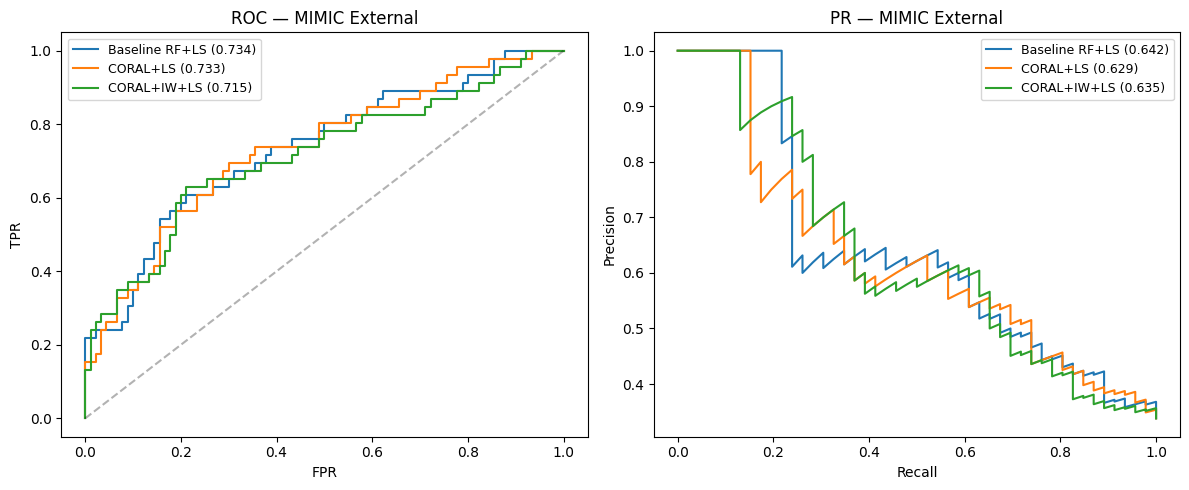

In [ ]:
rows = [
    ('Baseline RF + LS',   ref_val_res['auc'],   ref_mimic_res['auc'],   ref_mimic_res['pr'],   ref_mimic_res['sens'],   ref_mimic_res['spec']),
    ('CORAL + LS',         coral_val_res['auc'], coral_mimic_res['auc'], coral_mimic_res['pr'], coral_mimic_res['sens'], coral_mimic_res['spec']),
    ('CORAL + IW + LS',    ciw_val_res['auc'],   ciw_mimic_res['auc'],   ciw_mimic_res['pr'],   ciw_mimic_res['sens'],   ciw_mimic_res['spec']),
]
cols = ['Method', 'Val AUC', 'MIMIC AUC', 'MIMIC PR', 'MIMIC Sens', 'MIMIC Spec']
df_cmp = pd.DataFrame(rows, columns=cols).set_index('Method')
print(df_cmp.round(3).to_string())
print(f'\nCovariance reduction: {frob_before:.2f} → {frob_after:.2f}  ({reduction:.1f}% reduction)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
combos = [
    (y_mimic, p_ref_mimic_ls,   'Baseline RF+LS'),
    (y_mimic, p_coral_mimic_ls, 'CORAL+LS'),
    (y_mimic, p_ciw_mimic_ls,   'CORAL+IW+LS'),
]
for ax, mode in zip(axes, ['ROC', 'PR']):
    for y, p, lbl in combos:
        if mode == 'ROC':
            fpr, tpr, _ = roc_curve(y, p)
            ax.plot(fpr, tpr, label=f'{lbl} ({roc_auc_score(y,p):.3f})')
        else:
            prec, rec, _ = precision_recall_curve(y, p)
            ax.plot(rec, prec, label=f'{lbl} ({average_precision_score(y,p):.3f})')
    if mode == 'ROC':
        ax.plot([0,1],[0,1],'k--',alpha=0.3)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    else:
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'{mode} — MIMIC External'); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/AI in Medicine/documents/coral_roc_pr.png', dpi=150)
plt.show()

## 6. Save

In [ ]:
with open(f'{CORAL_DIR}/rf_coral_80.pkl',     'wb') as f: pickle.dump(rf_coral_cal, f)
with open(f'{CORAL_DIR}/rf_coral_iw_80.pkl',  'wb') as f: pickle.dump(rf_ciw_cal,   f)
np.save(f'{CORAL_DIR}/coral_W.npy', W)

coral_results = {
    'cont_cols_used':   len(coral_cols),
    'frob_before':      frob_before,
    'frob_after':       frob_after,
    'frob_reduction_pct': reduction,
    'coral_ls':         {k: float(v) for k,v in coral_mimic_res.items()},
    'coral_iw_ls':      {k: float(v) for k,v in ciw_mimic_res.items()},
    'coral_val_thr':    coral_val_thr,
    'ciw_val_thr':      ciw_val_thr,
}
with open(f'{CORAL_DIR}/coral_results_80.json', 'w') as f:
    json.dump(coral_results, f, indent=2)

print('Saved to models/coral_80/')
print(json.dumps(coral_results, indent=2))

Saved to models/coral_80/
{
  "cont_cols_used": 46,
  "frob_before": 18.912832033713652,
  "frob_after": 0.003211407833084729,
  "frob_reduction_pct": 99.98301995265774,
  "coral_ls": {
    "auc": 0.7326086956521739,
    "pr": 0.629160988556151,
    "sens": 0.6304347826086957,
    "spec": 0.7333333333333333
  },
  "coral_iw_ls": {
    "auc": 0.7152173913043478,
    "pr": 0.6353749248866619,
    "sens": 0.5869565217391305,
    "spec": 0.8111111111111111
  },
  "coral_val_thr": 0.07883859561552259,
  "ciw_val_thr": 0.04841245619266308
}
